
Weight Initialization Summary



,Initialization,Matrix Size,Mean,Std Dev,Min,Max
0,Random Normal,10 x 10,0.037141,1.029601,-2.613322,3.410503
1,Xavier Uniform,10 x 10,-0.037709,0.297202,-0.528241,0.520015
2,He / Kaiming Uniform,10 x 10,-0.032159,0.421633,-0.767740,0.766261
3,Random Normal,100 x 100,-0.016610,1.007665,-4.343280,4.101493
4,Xavier Uniform,100 x 100,0.001442,0.099978,-0.173146,0.173170
5,He / Kaiming Uniform,100 x 100,0.002122,0.140504,-0.244942,0.244854
6,Random Normal,500 x 500,0.001602,0.999231,-4.256578,4.519047
7,Xavier Uniform,500 x 500,0.000139,0.044720,-0.077460,0.077460
8,He / Kaiming Uniform,500 x 500,0.000020,0.063183,-0.109544,0.109543
9,Random Normal,1000 x 1000,0.000305,0.999031,-5.076314,4.827168


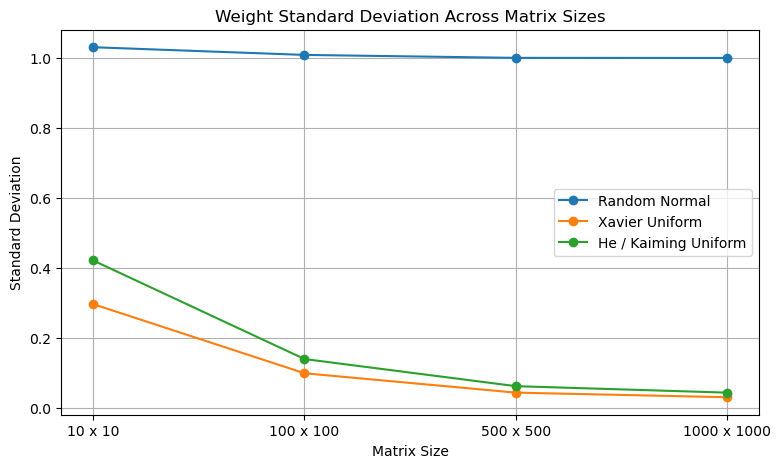

In [1]:
# Weight Initialization Techniques
# Comparing Random, Xavier, and He Initialization in PyTorch

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# 1. Set Random Seed
# --------------------------------------------------

torch.manual_seed(0)

# --------------------------------------------------
# 2. Define Matrix Sizes
# --------------------------------------------------

matrix_sizes = [
    (10, 10),
    (100, 100),
    (500, 500),
    (1000, 1000)
]

# --------------------------------------------------
# 3. Create Helper Function
# --------------------------------------------------

def summarize_weights(weights, method_name, matrix_size):
    return {
        "Initialization": method_name,
        "Matrix Size": f"{matrix_size[0]} x {matrix_size[1]}",
        "Mean": weights.mean().item(),
        "Std Dev": weights.std().item(),
        "Min": weights.min().item(),
        "Max": weights.max().item()
    }

# --------------------------------------------------
# 4. Apply Different Initialization Methods
# --------------------------------------------------

results = []

for matrix_size in matrix_sizes:

    rows, cols = matrix_size

    # Random Normal Initialization
    random_weights = torch.randn(rows, cols)

    results.append(
        summarize_weights(
            random_weights,
            "Random Normal",
            matrix_size
        )
    )

    # Xavier Initialization
    xavier_weights = torch.empty(rows, cols)

    nn.init.xavier_uniform_(xavier_weights)

    results.append(
        summarize_weights(
            xavier_weights,
            "Xavier Uniform",
            matrix_size
        )
    )

    # He Initialization
    he_weights = torch.empty(rows, cols)

    nn.init.kaiming_uniform_(
        he_weights,
        nonlinearity="relu"
    )

    results.append(
        summarize_weights(
            he_weights,
            "He / Kaiming Uniform",
            matrix_size
        )
    )

# --------------------------------------------------
# 5. Display Summary Table
# --------------------------------------------------

results_df = pd.DataFrame(results)

print("\nWeight Initialization Summary\n")
display(results_df)

# --------------------------------------------------
# 6. Plot Standard Deviation Comparison
# --------------------------------------------------

plt.figure(figsize=(9, 5))

for method in results_df["Initialization"].unique():

    subset = results_df[
        results_df["Initialization"] == method
    ]

    plt.plot(
        subset["Matrix Size"],
        subset["Std Dev"],
        marker="o",
        label=method
    )

plt.xlabel("Matrix Size")
plt.ylabel("Standard Deviation")
plt.title("Weight Standard Deviation Across Matrix Sizes")
plt.legend()
plt.grid(True)
plt.show()


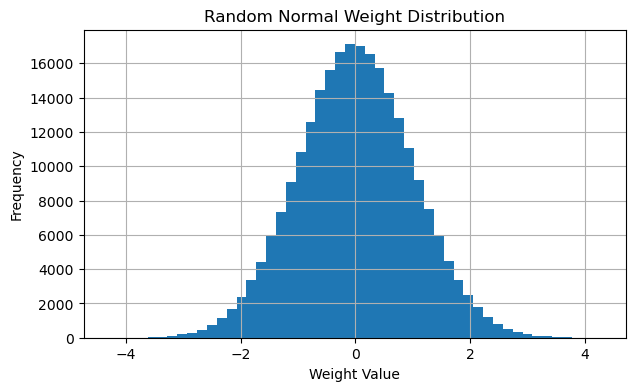

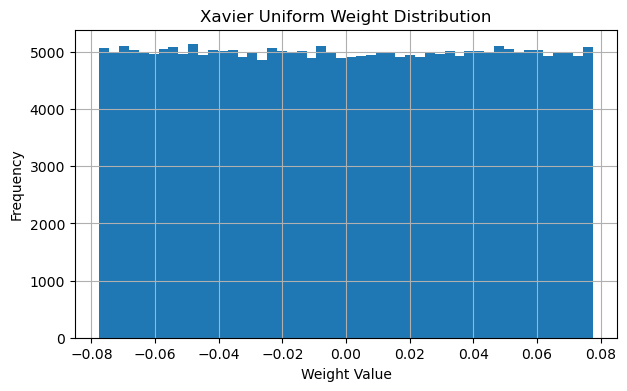

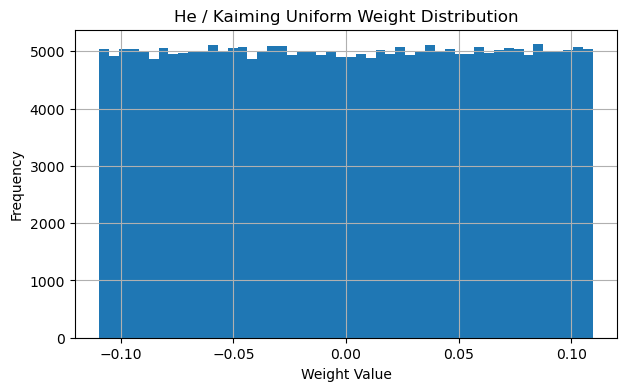

In [2]:

# --------------------------------------------------
# 7. Visualize Weight Distributions
# --------------------------------------------------

rows, cols = 500, 500

random_weights = torch.randn(rows, cols)

xavier_weights = torch.empty(rows, cols)
nn.init.xavier_uniform_(xavier_weights)

he_weights = torch.empty(rows, cols)
nn.init.kaiming_uniform_(
    he_weights,
    nonlinearity="relu"
)

weight_sets = {
    "Random Normal": random_weights.flatten(),
    "Xavier Uniform": xavier_weights.flatten(),
    "He / Kaiming Uniform": he_weights.flatten()
}

for name, values in weight_sets.items():

    plt.figure(figsize=(7, 4))

    plt.hist(
        values.numpy(),
        bins=50
    )

    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.title(f"{name} Weight Distribution")
    plt.grid(True)
    plt.show()


In [3]:

# --------------------------------------------------
# 8. Define Neural Network
# --------------------------------------------------

class SimpleNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)

        return x

# --------------------------------------------------
# 9. Define Initialization Function
# --------------------------------------------------

def initialize_model(model, method="he"):

    for layer in model.modules():

        if isinstance(layer, nn.Linear):

            if method == "random":

                nn.init.normal_(
                    layer.weight,
                    mean=0.0,
                    std=1.0
                )

            elif method == "xavier":

                nn.init.xavier_uniform_(
                    layer.weight
                )

            elif method == "he":

                nn.init.kaiming_uniform_(
                    layer.weight,
                    nonlinearity="relu"
                )

            else:
                raise ValueError(
                    "Unsupported initialization method"
                )

            nn.init.zeros_(layer.bias)

# --------------------------------------------------
# 10. Compare Initialized Neural Networks
# --------------------------------------------------

initialization_methods = [
    "random",
    "xavier",
    "he"
]

network_results = []

for method in initialization_methods:

    model = SimpleNetwork()

    initialize_model(
        model,
        method=method
    )

    first_layer_weights = model.fc1.weight.data

    network_results.append({
        "Method": method,
        "First Layer Mean": first_layer_weights.mean().item(),
        "First Layer Std Dev": first_layer_weights.std().item(),
        "First Layer Min": first_layer_weights.min().item(),
        "First Layer Max": first_layer_weights.max().item()
    })

network_results_df = pd.DataFrame(network_results)

print("\nNeural Network Initialization Comparison\n")
display(network_results_df)


Neural Network Initialization Comparison



,Method,First Layer Mean,First Layer Std Dev,First Layer Min,First Layer Max
0,random,-0.000143,1.003342,-4.117570,4.662310
1,xavier,-0.000033,0.043785,-0.075955,0.075955
2,he,-0.000078,0.050581,-0.087479,0.087480
